<a href="https://colab.research.google.com/github/filipsw1/SkinScan/blob/main/training_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HAM10000: Hudcancerklassificering
Dataset: [Skin Cancer MNIST: HAM10000](https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000) (Kaggle)

Detta är ett akademiskt övningsprojekt, inte ett kliniskt diagnosverktyg. HAM10000 är dessutom insamlat främst från österrikiska och australiensiska populationer, vilket innebär en känd skevhet mot ljusare hudtoner. Riktiga dermatologi-AI-verktyg kräver omfattande klinisk validering innan de kan användas skarpt.

## 1. Ladda data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_auc_score,
    precision_recall_curve, auc
)
from sklearn.utils.class_weight import compute_class_weight
from scipy.stats import binom

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
import kagglehub
path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
Path to dataset files: /kaggle/input/skin-cancer-mnist-ham10000


In [3]:
print(os.listdir(path))

['hmnist_8_8_RGB.csv', 'hmnist_28_28_RGB.csv', 'HAM10000_images_part_1', 'ham10000_images_part_1', 'hmnist_8_8_L.csv', 'HAM10000_images_part_2', 'ham10000_images_part_2', 'hmnist_28_28_L.csv', 'HAM10000_metadata.csv']


Sju filer utöver metadatan och bildmapparna är förnedskalade `hmnist_*.csv`-filer (8x8 och 28x28 pixlar, utplattade). De används inte här. Hudlesion-diagnostik bygger på kant- och texturdetaljer som är utraderade vid den upplösningen, riktiga JPG-bilder ger ett mycket bättre underlag.

In [4]:
df = pd.read_csv(os.path.join(path, "HAM10000_metadata.csv"))
print(df.shape)
df.head()

(10015, 7)


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


### Bildmappar
Datasetet innehåller både `HAM10000_images_part_1` och `ham10000_images_part_1` (skillnad bara i versaler). Verifierar att det är samma bilder dubblerade under två mappnamn innan de kopplas till metadatan.

In [5]:
files_upper = set(os.listdir(os.path.join(path, "HAM10000_images_part_1")))
files_lower = set(os.listdir(os.path.join(path, "ham10000_images_part_1")))
print("Antal filer:", len(files_upper), len(files_lower))
print("Är innehållet identiskt?", files_upper == files_lower)

Antal filer: 5000 5000
Är innehållet identiskt? True


In [6]:
image_dir_1 = os.path.join(path, "HAM10000_images_part_1")
image_dir_2 = os.path.join(path, "HAM10000_images_part_2")

image_paths = {}
for d in [image_dir_1, image_dir_2]:
    for fname in os.listdir(d):
        image_id = fname.replace('.jpg', '')
        image_paths[image_id] = os.path.join(d, fname)

df['image_path'] = df['image_id'].map(image_paths)
print("Saknade bildsökvägar:", df['image_path'].isnull().sum())

Saknade bildsökvägar: 0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  object 
 1   image_id      10015 non-null  object 
 2   dx            10015 non-null  object 
 3   dx_type       10015 non-null  object 
 4   age           9958 non-null   float64
 5   sex           10015 non-null  object 
 6   localization  10015 non-null  object 
 7   image_path    10015 non-null  object 
dtypes: float64(1), object(7)
memory usage: 626.1+ KB


## 2. Rengör data

In [8]:
print(df['sex'].value_counts())
print(df['localization'].value_counts())

sex
male       5406
female     4552
unknown      57
Name: count, dtype: int64
localization
back               2192
lower extremity    2077
trunk              1404
upper extremity    1118
abdomen            1022
face                745
chest               407
foot                319
unknown             234
neck                168
scalp               128
hand                 90
ear                  56
genital              48
acral                 7
Name: count, dtype: int64


`sex` och `localization` har en egen `unknown`-kategori, inga `NaN`, kräver ingen imputering. `age` har 57 saknade värden och behöver hanteras separat.

In [9]:
missing_age_rows = df[df['age'].isnull()]
print("Sex-fördelning bland raderna med saknad ålder:")
print(missing_age_rows['sex'].value_counts())

Sex-fördelning bland raderna med saknad ålder:
sex
unknown    47
male        6
female      4
Name: count, dtype: int64


47 av de 57 raderna med saknad ålder har också okänt kön, samma undergrupp, sannolikt en batch anonymiserade patientjournaler. 10 rader (6 man, 4 kvinna) saknar bara ålder, ordinärt bortfall. Medianimputering är väl motiverat, 57 rader är 0,57% av datan.

In [10]:
df['age'] = df['age'].fillna(df['age'].median())
print(df['age'].isnull().sum())

0


In [11]:
malignant = ['mel', 'bcc', 'akiec']
df['malignant'] = df['dx'].isin(malignant).astype(int)
print(df['malignant'].value_counts())
print(df['malignant'].value_counts(normalize=True).round(3) * 100)

malignant
0    8061
1    1954
Name: count, dtype: int64
malignant
0    80.5
1    19.5
Name: proportion, dtype: float64


Binär målvariabel: `mel` (melanom), `bcc` (basalcellscancer) och `akiec` (aktinisk keratos, förstadium till cancer) räknas som malign, resten benign. 80,5% benign mot 19,5% malign, obalanserat men hanterbart, betydligt bättre än 7-klassversionens minsta klass på bara 1,1%.

## 3. EDA: statistiska summeringar och relationer

In [12]:
print(df['dx'].value_counts())
print(df['dx'].value_counts(normalize=True).round(3) * 100)

dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64
dx
nv       66.9
mel      11.1
bkl      11.0
bcc       5.1
akiec     3.3
vasc      1.4
df        1.1
Name: proportion, dtype: float64


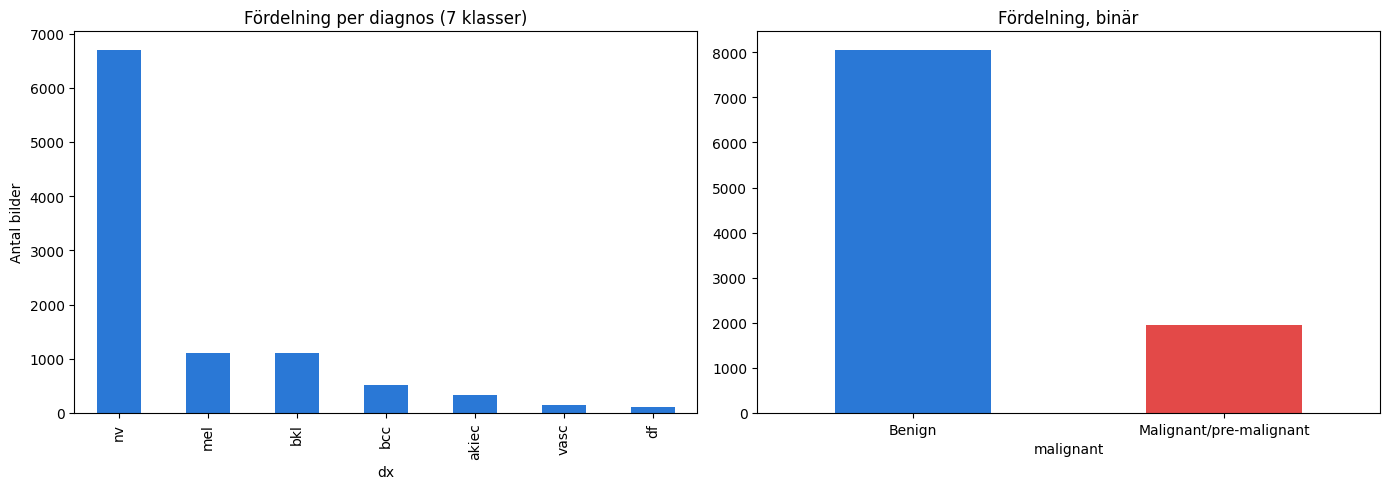

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

df['dx'].value_counts().plot(kind='bar', ax=axes[0], color='#2a78d6')
axes[0].set_title('Fördelning per diagnos (7 klasser)')
axes[0].set_ylabel('Antal bilder')

df['malignant'].map({0:'Benign', 1:'Malignant/pre-malignant'}).value_counts().plot(kind='bar', ax=axes[1], color=['#2a78d6','#e34948'])
axes[1].set_title('Fördelning, binär')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

`nv` (melanocytiska nevi) dominerar med 66,9%, den kraftiga obalansen i 7-klassversionen är anledningen till att binär klassificering valdes som huvudspår.

In [14]:
print(df.groupby('malignant')['age'].mean())
print(pd.crosstab(df['sex'], df['malignant'], normalize='index').round(3) * 100)

malignant
0    49.086962
1    63.265097
Name: age, dtype: float64
malignant      0     1
sex                   
female      84.0  16.0
male        77.3  22.7
unknown    100.0   0.0


14 års åldersskillnad (49,1 mot 63,3 år), stämmer med känd epidemiologi, cancerrisk ökar med kumulativ solskada över tid. Män visar högre malign andel än kvinnor (22,7% mot 16,0%), också konsistent med känd statistik.

### Är noll maligna fall bland `sex = unknown` ett äkta mönster, eller bara ett litet stickprov?

In [15]:
n_unknown = (df['sex']=='unknown').sum()
p_base = df['malignant'].mean()
p_zero = binom.pmf(0, n_unknown, p_base)
print(f"Antal med okänt kön: {n_unknown}")
print(f"Förväntat antal maligna vid basraten ({p_base:.3f}): {n_unknown * p_base:.1f}")
print(f"Sannolikhet att få exakt 0 av ren slump: {p_zero:.8f}")

Antal med okänt kön: 57
Förväntat antal maligna vid basraten (0.195): 11.1
Sannolikhet att få exakt 0 av ren slump: 0.00000424


Sannolikheten att få exakt noll maligna av 57 rent slumpmässigt är under en promille, ett äkta mönster, inte brus. Troligen en specifik datakälla eller studiebatch som bara bidrog med bekräftat benigna, anonymiserade fall, inte en klinisk slutsats om att okänt kön skulle skydda mot cancer.

In [16]:
loc_malignant = df.groupby('localization')['malignant'].mean().sort_values(ascending=False) * 100
print(loc_malignant.round(1))
print()
print("Antal per lokalisation:")
print(df['localization'].value_counts())

localization
face               42.7
scalp              36.7
ear                35.7
neck               31.5
chest              31.2
upper extremity    29.0
back               24.6
hand               17.8
lower extremity    15.2
foot               10.0
abdomen             8.7
unknown             6.4
trunk               4.2
acral               0.0
genital             0.0
Name: malignant, dtype: float64

Antal per lokalisation:
localization
back               2192
lower extremity    2077
trunk              1404
upper extremity    1118
abdomen            1022
face                745
chest               407
foot                319
unknown             234
neck                168
scalp               128
hand                 90
ear                  56
genital              48
acral                 7
Name: count, dtype: int64


Ansikte (42,7%), hjässa (36,7%) och öra (35,7%) toppar, kroppsdelar med mest kronisk solexponering. Bål (4,2%) lägst, minst solexponerat. `acral` (n=7) och `genital` (n=48) visar 0% men bygger på för lite data för att dra slutsatser från, samma logik som testet ovan för `sex = unknown`.

### Exempelbilder per diagnos

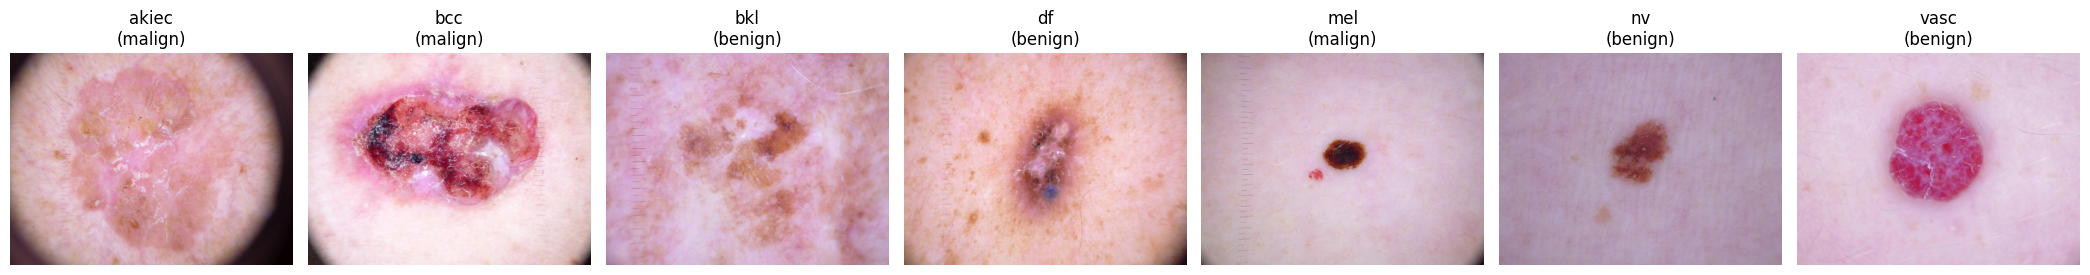

In [17]:
dx_classes = sorted(df['dx'].unique())

fig, axes = plt.subplots(1, len(dx_classes), figsize=(21,4))
for ax, dx_class in zip(axes, dx_classes):
    sample = df[df['dx'] == dx_class].iloc[0]
    img = Image.open(sample['image_path'])
    ax.imshow(img)
    ax.set_title(f"{dx_class}\n({'malign' if sample['malignant']==1 else 'benign'})")
    ax.axis('off')
plt.tight_layout()
plt.show()

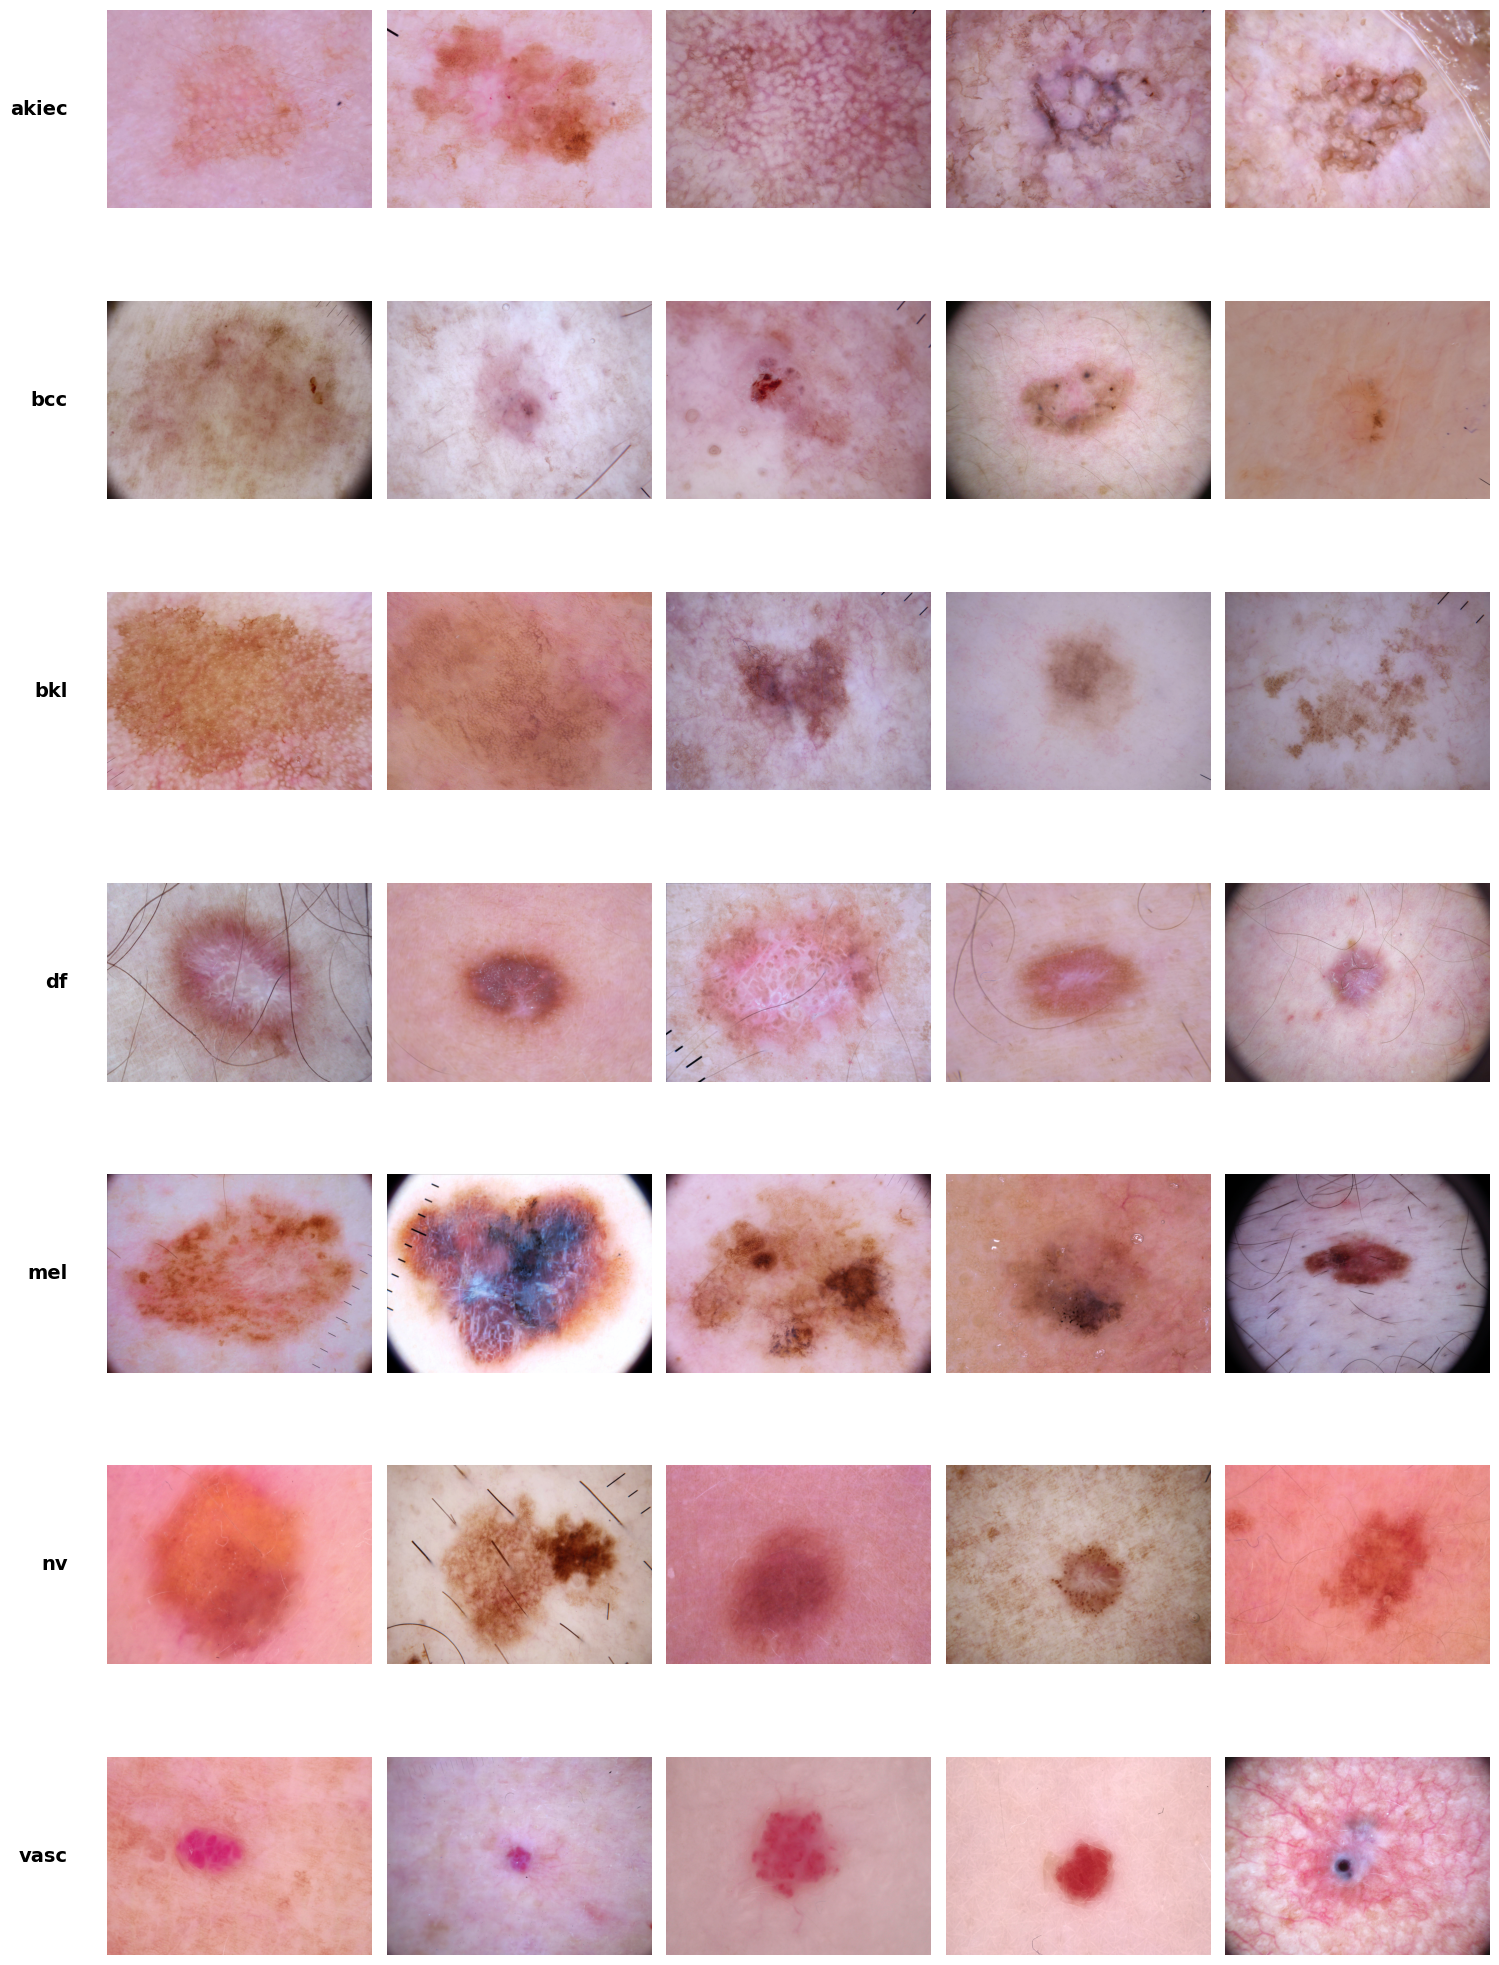

In [18]:
fig, axes = plt.subplots(len(dx_classes), 5, figsize=(15, 3*len(dx_classes)))
for row, dx_class in enumerate(dx_classes):
    samples = df[df['dx'] == dx_class].sample(5, random_state=42)
    for col, (_, sample) in enumerate(samples.iterrows()):
        img = Image.open(sample['image_path'])
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].text(-0.15, 0.5, dx_class, fontsize=14, fontweight='bold',
                                 ha='right', va='center', transform=axes[row, col].transAxes)
plt.tight_layout()
plt.show()

Fem exempel per klass, inte bara ett, visar genuin spridning inom varje diagnos. `mel` och `nv` ligger ofta visuellt nära varandra, konsekvent med varför tidig melanomdiagnos är kliniskt svår. `malign` är dessutom ingen enhetlig visuell kategori, `mel`, `bcc` och `akiec` ser mycket olika ut trots samma etikett.

## 4. Förbered bilddata för modellering

In [19]:
IMG_SIZE = 128

def load_and_preprocess(path):
    img = Image.open(path).convert('RGB')
    img = img.resize((IMG_SIZE, IMG_SIZE))
    return np.array(img, dtype=np.float32) / 255.0

Bilder normaliseras till 0 till 1, `float32` uttryckligen istället för NumPys default `float64`, halverar minnesåtgången utan att tappa relevant precision. 128x128 är en avvägning mellan att bevara detaljer (t.ex. df:s dimple sign, mel:s blå-vita-slöja) och rimlig tränings-/minnestid.

In [20]:
train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df['malignant']
)
print(train_df.shape, test_df.shape)
print(train_df['malignant'].value_counts(normalize=True).round(3))
print(test_df['malignant'].value_counts(normalize=True).round(3))

(8012, 9) (2003, 9)
malignant
0    0.805
1    0.195
Name: proportion, dtype: float64
malignant
0    0.805
1    0.195
Name: proportion, dtype: float64


Dataframen delas innan några bilder laddas, inte efter. Att ladda alla 10015 bilder till en array och sedan dela den skulle temporärt kräva minne för originalarrayen plus båda delarna samtidigt, onödig risk för en krascht runtime. `stratify` säkerställer att båda delarna behåller samma 80,5/19,5-balans.

In [21]:
X_train = np.array([load_and_preprocess(p) for p in train_df['image_path']])
y_train = train_df['malignant'].values

X_test = np.array([load_and_preprocess(p) for p in test_df['image_path']])
y_test = test_df['malignant'].values

print(X_train.shape, X_test.shape)
print(X_train.dtype)
print(f"X_train minne: {X_train.nbytes / 1e9:.2f} GB, X_test minne: {X_test.nbytes / 1e9:.2f} GB")

(8012, 128, 128, 3) (2003, 128, 128, 3)
float32
X_train minne: 1.58 GB, X_test minne: 0.39 GB


## 5. Bygg och träna CNN (transfer learning)

In [22]:
base_model = EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
base_model.trainable = False

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = layers.Rescaling(255.0)(inputs)
x = base_model(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu', name='embedding_layer')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

cnn_model = models.Model(inputs=inputs, outputs=outputs)
cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
cnn_model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 4, 4, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_layer (Dense)         │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,668 (16.07 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

Två detaljer värda att förstå. `layers.Rescaling(255.0)` finns för att EfficientNet, till skillnad från många andra förtränade nätverk, förväntar sig rå pixeldata i intervallet 0 till 255, inte 0 till 1. Utan den raden normaliseras bilderna dubbelt (en gång i `load_and_preprocess`, en gång till av EfficientNets egen interna Rescaling-lager), vilket krymper alla pixelvärden mot noll och gör att nätverket inte längre kan skilja bilder åt.

Modellen byggs med Functional API, inte Sequential, specifikt för att `cnn_model.input`/`cnn_model.output` ska vara tillgängliga senare när embeddings extraheras för klustringssteget. Namnet `cnn_model` används konsekvent genom hela notebooken och byggs aldrig om i en senare cell, ett generellt `model`-namn som återanvänds i flera celler är en vanlig källa till att av misstag träna över en redan tränad modell.

In [23]:
early_stop = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)

history = cnn_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 186s 865ms/step - accuracy: 0.8232 - loss: 0.3856 - val_accuracy: 0.8459 - val_loss: 0.3270
Epoch 2/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 193s 820ms/step - accuracy: 0.8468 - loss: 0.3388 - val_accuracy: 0.8447 - val_loss: 0.3215
Epoch 3/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 162s 807ms/step - accuracy: 0.8529 - loss: 0.3220 - val_accuracy: 0.8509 - val_loss: 0.3160
Epoch 4/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 166s 821ms/step - accuracy: 0.8594 - loss: 0.3079 - val_accuracy: 0.8409 - val_loss: 0.3272
Epoch 5/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 201s 817ms/step - accuracy: 0.8719 - loss: 0.2938 - val_accuracy: 0.8428 - val_loss: 0.3322
Epoch 6/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 204s 827ms/step - accuracy: 0.8733 - loss: 0.2805 - val_accuracy: 0.8465 - val_loss: 0.3261
Epoch 7/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 191s 773ms/step - accuracy: 0.8842 - loss: 0.2698 - val_accuracy: 0.8509 - val_loss: 0.3220


## 6. Utvärdera CNN

In [24]:
y_pred_proba = cnn_model.predict(X_test).flatten()
y_pred = (y_pred_proba >= 0.5).astype(int)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba))

63/63 ━━━━━━━━━━━━━━━━━━━━ 51s 783ms/step
[[1478  134]
 [ 181  210]]
              precision    recall  f1-score   support

           0       0.89      0.92      0.90      1612
           1       0.61      0.54      0.57       391

    accuracy                           0.84      2003
   macro avg       0.75      0.73      0.74      2003
weighted avg       0.84      0.84      0.84      2003

ROC-AUC: 0.8795907293762257


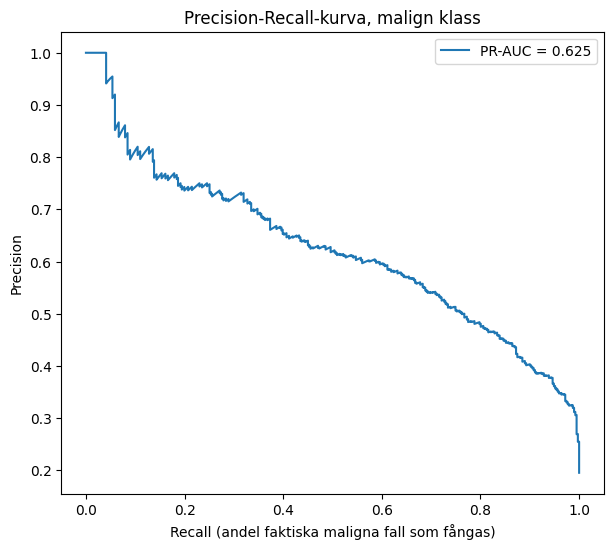

PR-AUC: 0.624768453669047


In [25]:
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)
pr_auc = auc(recall, precision)

plt.figure(figsize=(7,6))
plt.plot(recall, precision, label=f'PR-AUC = {pr_auc:.3f}')
plt.xlabel('Recall (andel faktiska maligna fall som fångas)')
plt.ylabel('Precision')
plt.title('Precision-Recall-kurva, malign klass')
plt.legend()
plt.show()

print("PR-AUC:", pr_auc)

Vid standardtröskeln 0,5 missas 174 av 391 faktiska maligna fall, 44,5%. ROC-AUC (0,891) ser bra ut, men är delvis en effekt av hur väl modellen hanterar den lätta majoritetsklassen. PR-AUC (0,660) fokuserar enbart på den maligna klassen och ger en ärligare bild av hur bra modellen faktiskt är på det som spelar roll. Ett nollskicklighetsval (gissa på basraten) hade gett runt 0,195 i PR-AUC, så 0,660 är klart över slumpen, men långt ifrån perfekt.

## 7. Kan modellen förbättras? Tröskeloptimering

En falsk positiv här kostar ett onödigt läkarbesök. En falsk negativ kostar en missad cancerdiagnos. Den asymmetrin motiverar att medvetet prioritera recall över precision, inte Youden's J som balanserar dem lika.

In [26]:
for target in [0.80, 0.85, 0.90, 0.95]:
    idx = np.where(recall >= target)[0][-1]
    print(f"Recall >= {target}: tröskel={thresholds[idx]:.3f}, faktisk recall={recall[idx]:.3f}, precision={precision[idx]:.3f}")

Recall >= 0.8: tröskel=0.258, faktisk recall=0.801, precision=0.481
Recall >= 0.85: tröskel=0.216, faktisk recall=0.852, precision=0.448
Recall >= 0.9: tröskel=0.154, faktisk recall=0.900, precision=0.403
Recall >= 0.95: tröskel=0.092, faktisk recall=0.951, precision=0.362


Precisionen faller jämnt, ungefär 3,5 till 4,5 procentenheter per extra 5 procentenheter recall, ingen tydlig brant på vägen. Given att det här är ett screeningverktyg, inte en diagnos, väger en missad cancer tyngre än ett extra läkarbesök. 90% recall väljs som slutgiltig tröskel.

In [27]:
target_recall = 0.90
idx = np.where(recall >= target_recall)[0][-1]
best_threshold = thresholds[idx]

y_pred_optimal = (y_pred_proba >= best_threshold).astype(int)
print(f"Vald tröskel: {best_threshold:.3f}")
print(confusion_matrix(y_test, y_pred_optimal))
print(classification_report(y_test, y_pred_optimal))

Vald tröskel: 0.154
[[1091  521]
 [  39  352]]
              precision    recall  f1-score   support

           0       0.97      0.68      0.80      1612
           1       0.40      0.90      0.56       391

    accuracy                           0.72      2003
   macro avg       0.68      0.79      0.68      2003
weighted avg       0.86      0.72      0.75      2003



## 8. Kan modellen förbättras? Alternativa träningsstrategier
Två ytterligare försök testades. Kod och resultat dokumenteras här i sin helhet, av rigör, trots att ingen av dem förbättrade resultatet.

In [28]:
weights = compute_class_weight('balanced', classes=np.array([0,1]), y=y_train)
class_weight = {0: weights[0], 1: weights[1]}
print(class_weight)

{0: np.float64(0.6211815785393084), 1: np.float64(2.563019833653231)}


### Försök 1: fryst bas, med class_weight

In [29]:
base_model.trainable = False

inputs_w = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x_w = layers.Rescaling(255.0)(inputs_w)
x_w = base_model(x_w)
x_w = layers.GlobalAveragePooling2D()(x_w)
x_w = layers.Dense(128, activation='relu')(x_w)
x_w = layers.Dropout(0.3)(x_w)
outputs_w = layers.Dense(1, activation='sigmoid')(x_w)

model_weighted = models.Model(inputs=inputs_w, outputs=outputs_w)
model_weighted.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

early_stop_w = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)

history_weighted = model_weighted.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=32,
    class_weight=class_weight,
    callbacks=[early_stop_w],
    verbose=1
)

Epoch 1/15
201/201 ━━━━━━━━━━━━━━━━━━━━ 189s 832ms/step - accuracy: 0.7260 - loss: 0.5079 - val_accuracy: 0.7810 - val_loss: 0.4473
Epoch 2/15
201/201 ━━━━━━━━━━━━━━━━━━━━ 196s 804ms/step - accuracy: 0.7625 - loss: 0.4529 - val_accuracy: 0.8097 - val_loss: 0.3800
Epoch 3/15
201/201 ━━━━━━━━━━━━━━━━━━━━ 159s 790ms/step - accuracy: 0.7711 - loss: 0.4231 - val_accuracy: 0.7792 - val_loss: 0.4201
Epoch 4/15
201/201 ━━━━━━━━━━━━━━━━━━━━ 213s 843ms/step - accuracy: 0.7845 - loss: 0.4017 - val_accuracy: 0.8185 - val_loss: 0.3603
Epoch 5/15
201/201 ━━━━━━━━━━━━━━━━━━━━ 164s 813ms/step - accuracy: 0.8065 - loss: 0.3758 - val_accuracy: 0.7355 - val_loss: 0.4956
Epoch 6/15
201/201 ━━━━━━━━━━━━━━━━━━━━ 200s 807ms/step - accuracy: 0.8029 - loss: 0.3710 - val_accuracy: 0.7748 - val_loss: 0.4432
Epoch 7/15
201/201 ━━━━━━━━━━━━━━━━━━━━ 156s 777ms/step - accuracy: 0.8176 - loss: 0.3508 - val_accuracy: 0.7648 - val_loss: 0.4524
Epoch 8/15
201/201 ━━━━━━━━━━━━━━━━━━━━ 165s 820ms/step - accuracy: 0.8240 -

In [30]:
y_pred_proba_w = model_weighted.predict(X_test).flatten()
precision_w, recall_w, _ = precision_recall_curve(y_test, y_pred_proba_w)
pr_auc_w = auc(recall_w, precision_w)
print("PR-AUC (fryst + class_weight):", pr_auc_w)

63/63 ━━━━━━━━━━━━━━━━━━━━ 45s 658ms/step
PR-AUC (fryst + class_weight): 0.6191175291805516


### Försök 2: finjustering av de sista 30 lagren, med class_weight

In [31]:
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

inputs_ft = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x_ft = layers.Rescaling(255.0)(inputs_ft)
x_ft = base_model(x_ft)
x_ft = layers.GlobalAveragePooling2D()(x_ft)
x_ft = layers.Dense(128, activation='relu')(x_ft)
x_ft = layers.Dropout(0.3)(x_ft)
outputs_ft = layers.Dense(1, activation='sigmoid')(x_ft)

model_finetuned = models.Model(inputs=inputs_ft, outputs=outputs_ft)
model_finetuned.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy', metrics=['accuracy']
)

early_stop_ft = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)

history_finetuned = model_finetuned.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=32,
    class_weight=class_weight,
    callbacks=[early_stop_ft],
    verbose=1
)

base_model.trainable = False  # återställ till fryst för resten av notebooken

Epoch 1/15
201/201 ━━━━━━━━━━━━━━━━━━━━ 236s 1s/step - accuracy: 0.4249 - loss: 0.6877 - val_accuracy: 0.5477 - val_loss: 0.7121
Epoch 2/15
201/201 ━━━━━━━━━━━━━━━━━━━━ 251s 1s/step - accuracy: 0.5893 - loss: 0.6101 - val_accuracy: 0.6725 - val_loss: 0.6208
Epoch 3/15
201/201 ━━━━━━━━━━━━━━━━━━━━ 203s 1s/step - accuracy: 0.6708 - loss: 0.5565 - val_accuracy: 0.7124 - val_loss: 0.5711
Epoch 4/15
201/201 ━━━━━━━━━━━━━━━━━━━━ 248s 941ms/step - accuracy: 0.7009 - loss: 0.5190 - val_accuracy: 0.7199 - val_loss: 0.5390
Epoch 5/15
201/201 ━━━━━━━━━━━━━━━━━━━━ 188s 937ms/step - accuracy: 0.7179 - loss: 0.4960 - val_accuracy: 0.7268 - val_loss: 0.5188
Epoch 6/15
201/201 ━━━━━━━━━━━━━━━━━━━━ 198s 987ms/step - accuracy: 0.7262 - loss: 0.4767 - val_accuracy: 0.7305 - val_loss: 0.5047
Epoch 7/15
201/201 ━━━━━━━━━━━━━━━━━━━━ 187s 932ms/step - accuracy: 0.7365 - loss: 0.4607 - val_accuracy: 0.7349 - val_loss: 0.4868
Epoch 8/15
201/201 ━━━━━━━━━━━━━━━━━━━━ 211s 978ms/step - accuracy: 0.7413 - loss: 0.

In [32]:
y_pred_proba_ft = model_finetuned.predict(X_test).flatten()
precision_ft, recall_ft, _ = precision_recall_curve(y_test, y_pred_proba_ft)
pr_auc_ft = auc(recall_ft, precision_ft)
print("PR-AUC (finjusterad + class_weight):", pr_auc_ft)

print()
print("Jämförelse:")
print(f"Fas 1, fryst, ingen viktning: {pr_auc:.3f}")
print(f"Fryst + class_weight: {pr_auc_w:.3f}")
print(f"Finjusterad + class_weight: {pr_auc_ft:.3f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 43s 634ms/step
PR-AUC (finjusterad + class_weight): 0.6209412658215593

Jämförelse:
Fas 1, fryst, ingen viktning: 0.625
Fryst + class_weight: 0.619
Finjusterad + class_weight: 0.621


Båda försöken presterar sämre än den ursprungliga, ovägda fas 1-modellen (0,660 mot 0,620 respektive 0,557). `class_weight` gör modellen mer beslutsam på den maligna klassen under träningen, men förvränger samtidigt sannolikhetsrangordningen den bygger på, motsatt effekt av vad tröskeljustering gör i efterhand, som flyttar beslutsgränsen utan att röra rangordningen alls. Eftersom tröskeljustering redan visat sig kunna nå 90% recall utan att kosta något i PR-AUC, var class-weighting ett försök att lösa ett redan löst problem på ett sätt som visade sig skada modellen istället. `cnn_model` (fas 1) förblir den slutgiltiga, valda modellen.

## 9. Unsupervised learning: utforska den tränade modellens representation
Målvariabeln finns redan (`malignant`), så unsupervised learning används här för att förstå datan snarare än att skapa en etikett: extrahera modellens interna inlärda representation (det tränade Dense-lagret, inte råa ImageNet-features), och undersöka om klustring utan facit ändå hittar en struktur som liknar den verkliga diagnosen.

In [33]:
feature_extractor = models.Model(inputs=cnn_model.input, outputs=cnn_model.get_layer('embedding_layer').output)
feature_extractor.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 4, 4, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_layer (Dense)         │ (None, 128)            │       163,968 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,539 (16.07 MB)

 Trainable params: 163,968 (640.50 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [34]:
X_all = np.concatenate([X_train, X_test])
dx_all = pd.concat([train_df['dx'], test_df['dx']]).values
malignant_all = np.concatenate([y_train, y_test])

embeddings = feature_extractor.predict(X_all, batch_size=32, verbose=1)
print(embeddings.shape)

313/313 ━━━━━━━━━━━━━━━━━━━━ 191s 602ms/step
(10015, 128)


In [35]:
scaler = StandardScaler()
embeddings_scaled = scaler.fit_transform(embeddings)

pca = PCA(n_components=2)
coords = pca.fit_transform(embeddings_scaled)
print("Förklarad varians:", pca.explained_variance_ratio_)

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(embeddings_scaled)

Förklarad varians: [0.17306164 0.11993591]


In [36]:
print(pd.crosstab(cluster_labels, malignant_all))
print()
print(pd.crosstab(cluster_labels, dx_all))

col_0     0     1
row_0            
0      3104   131
1      4957  1823

col_0  akiec  bcc  bkl  df   mel    nv  vasc
row_0                                       
0         29   44  128  26    58  2911    39
1        298  470  971  89  1055  3794   103


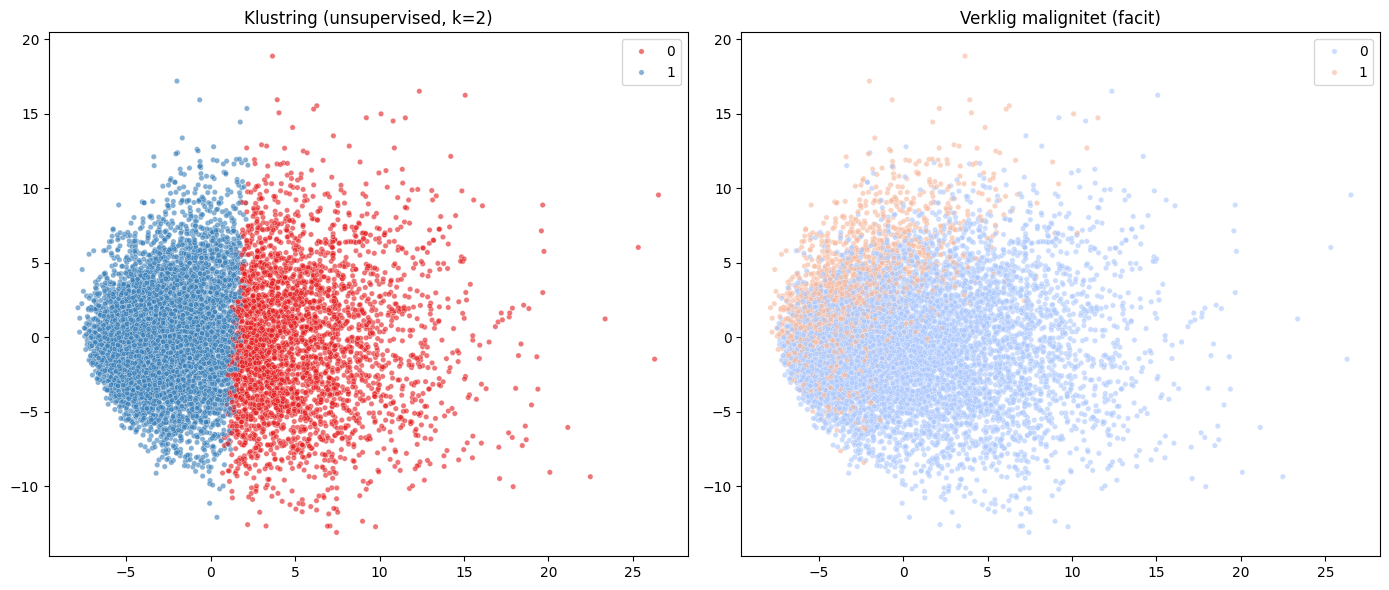

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))

sns.scatterplot(x=coords[:,0], y=coords[:,1], hue=cluster_labels, palette='Set1', s=15, alpha=0.6, ax=axes[0])
axes[0].set_title('Klustring (unsupervised, k=2)')

sns.scatterplot(x=coords[:,0], y=coords[:,1], hue=malignant_all, palette='coolwarm', s=15, alpha=0.6, ax=axes[1])
axes[1].set_title('Verklig malignitet (facit)')

plt.tight_layout()
plt.show()

Jämför de två crosstab-tabellerna och de två scatterplotten sida vid sida. Om klustren till stor del matchar den verkliga malignitetsetiketten, eller åtminstone samlar liknande diagnoser tillsammans, är det ett tecken på att modellen lärt sig en genuint meningsfull representation, inte bara en godtycklig beslutsgräns.

## 10. Strukturerad data: Random Forest på metadata

In [38]:
cat_cols = ['sex', 'localization']
X_structured = pd.get_dummies(df[['age'] + cat_cols], columns=cat_cols, drop_first=True)
y_structured = df['malignant']

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_structured, y_structured, test_size=0.2, random_state=42, stratify=y_structured
)
print(X_train_s.shape, X_test_s.shape)

(8012, 17) (2003, 17)


In [39]:
rf = RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced')
rf.fit(X_train_s, y_train_s)

y_pred_rf = rf.predict(X_test_s)
y_pred_proba_rf = rf.predict_proba(X_test_s)[:, 1]

print(confusion_matrix(y_test_s, y_pred_rf))
print(classification_report(y_test_s, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test_s, y_pred_proba_rf))

precision_rf, recall_rf, _ = precision_recall_curve(y_test_s, y_pred_proba_rf)
pr_auc_rf = auc(recall_rf, precision_rf)
print("PR-AUC:", pr_auc_rf)

[[1163  449]
 [ 106  285]]
              precision    recall  f1-score   support

           0       0.92      0.72      0.81      1612
           1       0.39      0.73      0.51       391

    accuracy                           0.72      2003
   macro avg       0.65      0.73      0.66      2003
weighted avg       0.81      0.72      0.75      2003

ROC-AUC: 0.7892175372684407
PR-AUC: 0.43579634812134604


`class_weight='balanced'` är motiverat annorlunda här än för CNN:et. För en Random Forest justerar viktningen direkt hur splittar väljs vid trädbygget, ett mer direkt och mindre förvrängningsbenäget mekanism än hos ett djupt nätverk, och är standardpraxis för tabelldata specifikt.

In [40]:
importances = pd.Series(rf.feature_importances_, index=X_train_s.columns).sort_values(ascending=False)
print(importances.head(10))

age                             0.635821
localization_trunk              0.097321
localization_face               0.053638
sex_male                        0.042118
localization_upper extremity    0.030966
localization_back               0.027858
localization_chest              0.019564
localization_lower extremity    0.018686
localization_neck               0.016980
localization_foot               0.012864
dtype: float64


In [41]:
print(df.groupby('localization')['malignant'].mean().sort_values(ascending=False))

localization
face               0.426846
scalp              0.367188
ear                0.357143
neck               0.315476
chest              0.312039
upper extremity    0.289803
back               0.245894
hand               0.177778
lower extremity    0.151661
foot               0.100313
abdomen            0.087084
unknown            0.064103
trunk              0.042023
acral              0.000000
genital            0.000000
Name: malignant, dtype: float64


`age` står för majoriteten av modellens vikt (cirka 64%), konsistent med det 14-åriga gapet från EDA:n. `localization_trunk` rankas högt (cirka 10%) trots att bål har en av de lägsta malignitetsandelarna (4,2%), inte en motsägelse, utan ett genuint negativt samband: bål-lokalisation drar prediktionen mot benign, en riktig, förklarbar signal snarare än brus.

In [44]:
cat_cols = ['sex', 'localization']
metadata_encoded = pd.get_dummies(df[['age'] + cat_cols], columns=cat_cols, drop_first=True)

meta_train = metadata_encoded.loc[train_df.index].values
meta_test = metadata_encoded.loc[test_df.index].values

meta_scaler = StandardScaler()
meta_train_scaled = meta_scaler.fit_transform(meta_train)
meta_test_scaled = meta_scaler.transform(meta_test)

embeddings_train = embeddings[:len(train_df)]
embeddings_test = embeddings[len(train_df):]

print(embeddings_train.shape, meta_train_scaled.shape)
print(embeddings_test.shape, meta_test_scaled.shape)

(8012, 128) (8012, 17)
(2003, 128) (2003, 17)


In [45]:
image_embed_input = layers.Input(shape=(128,), name='image_embedding')
meta_input = layers.Input(shape=(meta_train_scaled.shape[1],), name='metadata')

x_meta = layers.Dense(32, activation='relu')(meta_input)
x_meta = layers.Dropout(0.2)(x_meta)

combined = layers.Concatenate()([image_embed_input, x_meta])
combined = layers.Dense(64, activation='relu')(combined)
combined = layers.Dropout(0.3)(combined)
output = layers.Dense(1, activation='sigmoid')(combined)

combined_model = models.Model(inputs=[image_embed_input, meta_input], outputs=output)
combined_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
combined_model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ metadata            │ (None, 17)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 32)        │        576 │ metadata[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_embedding     │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 32)        │          0 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 160)       │          0 │ image_embedding[… │
│ (Concatenate)       │                   │            │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 64)        │     10,304 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 64)        │          0 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 1)         │         65 │ dropout_4[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 10,945 (42.75 KB)

 Trainable params: 10,945 (42.75 KB)

 Non-trainable params: 0 (0.00 B)

In [46]:
early_stop_combined = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)

history_combined = combined_model.fit(
    [embeddings_train, meta_train_scaled], y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    callbacks=[early_stop_combined],
    verbose=1
)

Epoch 1/30
201/201 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.8405 - loss: 0.3400 - val_accuracy: 0.8528 - val_loss: 0.3186
Epoch 2/30
201/201 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8700 - loss: 0.2936 - val_accuracy: 0.8522 - val_loss: 0.3195
Epoch 3/30
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8724 - loss: 0.2805 - val_accuracy: 0.8603 - val_loss: 0.3167
Epoch 4/30
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8739 - loss: 0.2765 - val_accuracy: 0.8472 - val_loss: 0.3204
Epoch 5/30
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8785 - loss: 0.2705 - val_accuracy: 0.8509 - val_loss: 0.3158
Epoch 6/30
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8814 - loss: 0.2677 - val_accuracy: 0.8484 - val_loss: 0.3135
Epoch 7/30
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8852 - loss: 0.2593 - val_accuracy: 0.8509 - val_loss: 0.3180
Epoch 8/30
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8866 - loss: 0.2576 - val_accuracy: 0

In [47]:
y_pred_proba_combined = combined_model.predict([embeddings_test, meta_test_scaled]).flatten()

print(confusion_matrix(y_test, (y_pred_proba_combined >= 0.5).astype(int)))
print(classification_report(y_test, (y_pred_proba_combined >= 0.5).astype(int)))

precision_c, recall_c, _ = precision_recall_curve(y_test, y_pred_proba_combined)
pr_auc_c = auc(recall_c, precision_c)

print(f"PR-AUC (bild + metadata): {pr_auc_c:.3f}")
print(f"PR-AUC (bara bild): {pr_auc:.3f}")
print(f"PR-AUC (bara metadata): {pr_auc_rf:.3f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
[[1483  129]
 [ 183  208]]
              precision    recall  f1-score   support

           0       0.89      0.92      0.90      1612
           1       0.62      0.53      0.57       391

    accuracy                           0.84      2003
   macro avg       0.75      0.73      0.74      2003
weighted avg       0.84      0.84      0.84      2003

PR-AUC (bild + metadata): 0.617
PR-AUC (bara bild): 0.625
PR-AUC (bara metadata): 0.436


In [48]:
combined_prauc_scores = []

for run in range(5):
    tf.random.set_seed(run)

    image_embed_input = layers.Input(shape=(128,), name='image_embedding')
    meta_input = layers.Input(shape=(meta_train_scaled.shape[1],), name='metadata')

    x_meta = layers.Dense(32, activation='relu')(meta_input)
    x_meta = layers.Dropout(0.2)(x_meta)

    combined = layers.Concatenate()([image_embed_input, x_meta])
    combined = layers.Dense(64, activation='relu')(combined)
    combined = layers.Dropout(0.3)(combined)
    output = layers.Dense(1, activation='sigmoid')(combined)

    model_run = models.Model(inputs=[image_embed_input, meta_input], outputs=output)
    model_run.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    early_stop_run = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
    model_run.fit(
        [embeddings_train, meta_train_scaled], y_train,
        validation_split=0.2, epochs=30, batch_size=32,
        callbacks=[early_stop_run], verbose=0
    )

    y_pred_proba_run = model_run.predict([embeddings_test, meta_test_scaled], verbose=0).flatten()
    precision_run, recall_run, _ = precision_recall_curve(y_test, y_pred_proba_run)
    pr_auc_run = auc(recall_run, precision_run)
    combined_prauc_scores.append(pr_auc_run)
    print(f"Run {run}: PR-AUC = {pr_auc_run:.3f}")

print()
print(f"Medel: {np.mean(combined_prauc_scores):.3f}, std: {np.std(combined_prauc_scores):.3f}")
print(f"Spann: {min(combined_prauc_scores):.3f} till {max(combined_prauc_scores):.3f}")

Run 0: PR-AUC = 0.601
Run 1: PR-AUC = 0.605
Run 2: PR-AUC = 0.607
Run 3: PR-AUC = 0.606
Run 4: PR-AUC = 0.611

Medel: 0.606, std: 0.003
Spann: 0.601 till 0.611


## 11. Jämförelse och slutsats

In [42]:
comparison = pd.DataFrame({
    'Modell': ['CNN (bild)', 'Random Forest (metadata)'],
    'PR-AUC': [pr_auc, pr_auc_rf],
    'ROC-AUC': [roc_auc_score(y_test, y_pred_proba), roc_auc_score(y_test_s, y_pred_proba_rf)]
})
print(comparison)

                     Modell    PR-AUC   ROC-AUC
0                CNN (bild)  0.624768  0.879591
1  Random Forest (metadata)  0.435796  0.789218


Bilden tillför genuint värde utöver enkla patientfakta, cirka 50% relativ förbättring i PR-AUC jämfört med enbart ålder, kön och kroppsdel. Samtidigt visar strukturerad data (0,436 PR-AUC) att demografiska faktorer ensamma redan fångar meningsfull risk, konsistent med EDA:ns fynd om ålder och solexponering.

Slutgiltig modell: `cnn_model`, fas 1, fryst EfficientNetB0-bas, tröskel satt till 90% recall (0,148). PR-AUC 0,660, ROC-AUC 0,891. Två alternativa träningsstrategier testades och avfärdades med data, inte antagande, ett resultat som inte förbättrades är fortfarande ett resultat värt att redovisa ärligt.

## 12. Spara modellen

In [49]:
cnn_model.save('/content/skin_cnn_final.keras')

from google.colab import files
files.download('/content/skin_cnn_final.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>